# Student Dropout Risk Prediction
## Notebook 5 — Recommendation Engine

**Prerequisites:** Run notebooks 1–4 first.

### Objectives
- Build a rule-based recommendation engine
- Map each student's top SHAP risk factors to targeted interventions
- Prioritise recommendations by SHAP weight and urgency
- Generate a full recommendations report for all at-risk students
- Save the engine for use in the Streamlit app

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load All Required Data

In [2]:
# Intervention library
with open('../app/intervention_library.json', 'r') as f:
    intervention_library = json.load(f)

rules = intervention_library['rules']
print(f'Intervention library loaded — {len(rules)} rules')

# Test set with predictions
test_predictions = pd.read_csv('../data/processed/test_predictions.csv')

# Per-student SHAP risk factors
risk_factors_df = pd.read_csv('../data/processed/student_risk_factors.csv')

# Full processed data
full_df = pd.read_csv('../data/processed/full_processed.csv')

# Feature names
FEATURE_NAMES = pd.read_csv('../data/processed/feature_names.csv', header=None)[0].tolist()

print(f'Test predictions  : {test_predictions.shape}')
print(f'Risk factors      : {risk_factors_df.shape}')
print(f'Full dataset      : {full_df.shape}')

Intervention library loaded — 20 rules
Test predictions  : (885, 49)
Risk factors      : (2655, 8)
Full dataset      : (4424, 47)


---
## 2. The Recommendation Engine

The engine works in three steps for each student:
1. Get their top SHAP risk factors
2. Match each factor against the intervention rules
3. Return ranked, deduplicated recommendations sorted by SHAP weight × urgency

In [3]:
URGENCY_WEIGHT = {'High': 3, 'Medium': 2, 'Low': 1}

def match_rules(feature_name, feature_value, shap_value, rules):
    """
    Check all rules and return matching interventions for a given feature.
    """
    matched = []
    for rule in rules:
        if rule['trigger_feature'] != feature_name:
            continue

        condition = rule['condition']
        threshold = rule['threshold']
        triggered = False

        if condition == 'low'    and feature_value <= threshold:
            triggered = True
        elif condition == 'high' and feature_value >= threshold:
            triggered = True
        elif condition == 'equals' and int(feature_value) == int(threshold):
            triggered = True

        if triggered:
            matched.append({
                'rule_id'             : rule['id'],
                'risk_category'       : rule['risk_category'],
                'intervention_title'  : rule['intervention_title'],
                'intervention_detail' : rule['intervention_detail'],
                'responsible_party'   : rule['responsible_party'],
                'urgency'             : rule['urgency'],
                'trigger_feature'     : feature_name,
                'feature_value'       : feature_value,
                'shap_value'          : shap_value
            })
    return matched


def get_recommendations(student_features, student_shap_values, feature_names, rules, top_n_factors=3):
    """
    Generate ranked recommendations for a single student.

    Parameters
    ----------
    student_features  : dict or pd.Series of feature_name -> feature_value
    student_shap_values: dict or pd.Series of feature_name -> shap_value
    feature_names     : list of all feature names
    rules             : list of intervention rules
    top_n_factors     : how many top SHAP risk factors to consider

    Returns
    -------
    List of recommendation dicts, sorted by priority score
    """
    # Get top N risk-driving features (positive SHAP only)
    shap_series = pd.Series(student_shap_values, index=feature_names)
    top_factors = shap_series[shap_series > 0].nlargest(top_n_factors)

    all_recommendations = []
    seen_titles = set()

    for feature_name, shap_val in top_factors.items():
        feature_val = student_features[feature_name]
        matches = match_rules(feature_name, feature_val, shap_val, rules)

        for rec in matches:
            # Deduplicate by intervention title
            if rec['intervention_title'] not in seen_titles:
                seen_titles.add(rec['intervention_title'])
                # Priority score = SHAP value × urgency weight
                rec['priority_score'] = round(
                    shap_val * URGENCY_WEIGHT[rec['urgency']], 4
                )
                all_recommendations.append(rec)

    # Sort by priority score descending
    all_recommendations.sort(key=lambda x: x['priority_score'], reverse=True)
    return all_recommendations


print('Recommendation engine functions defined.')

Recommendation engine functions defined.


---
## 3. Test on a Single High-Risk Student

In [4]:
# Load SHAP values for full dataset
shap_df = pd.read_csv('../data/processed/shap_values_full.csv')
shap_cols = [c for c in shap_df.columns if c.startswith('shap_')]

# Find the student with the highest risk score
high_risk_idx = shap_df['risk_score'].idxmax()
high_risk_score = shap_df.loc[high_risk_idx, 'risk_score']

# Get their features and SHAP values
student_features = full_df[FEATURE_NAMES].iloc[high_risk_idx]
student_shap     = shap_df[shap_cols].iloc[high_risk_idx]
student_shap.index = FEATURE_NAMES  # strip 'shap_' prefix

# Generate recommendations
recommendations = get_recommendations(
    student_features, student_shap, FEATURE_NAMES, rules, top_n_factors=5
)

print(f'Student index     : {high_risk_idx}')
print(f'Risk score        : {high_risk_score:.4f}')
print(f'Recommendations   : {len(recommendations)}')
print()

for i, rec in enumerate(recommendations, 1):
    print(f'--- Recommendation {i} ---')
    print(f'  Category    : {rec["risk_category"]}')
    print(f'  Title       : {rec["intervention_title"]}')
    print(f'  Urgency     : {rec["urgency"]}')
    print(f'  Responsible : {rec["responsible_party"]}')
    print(f'  Triggered by: {rec["trigger_feature"]} = {rec["feature_value"]}')
    print(f'  SHAP value  : {rec["shap_value"]:.4f}')
    print(f'  Priority    : {rec["priority_score"]:.4f}')
    print(f'  Detail      : {rec["intervention_detail"]}')
    print()

Student index     : 1134
Risk score        : 0.9997
Recommendations   : 4

--- Recommendation 1 ---
  Category    : Financial
  Title       : Financial counselling & fee assistance
  Urgency     : High
  Responsible : Financial aid office
  Triggered by: Tuition fees up to date = 0.0
  SHAP value  : 2.2242
  Priority    : 6.6726
  Detail      : Connect the student with the financial aid office immediately. Explore available scholarships, bursaries, emergency funds, or payment plan options. Ensure overdue fees do not result in sudden deregistration.

--- Recommendation 2 ---
  Category    : Academic
  Title       : Curriculum review meeting
  Urgency     : High
  Responsible : Academic advisor
  Triggered by: Approval_Rate_Sem2 = 0.0
  SHAP value  : 0.9670
  Priority    : 2.9010
  Detail      : Schedule a meeting with the student to review their subject choices and workload. Assess whether the course difficulty matches the student's preparation level. Explore bridging courses if needed.

---
## 4. Generate Recommendations for ALL At-Risk Students

In [5]:
def assign_risk_level(score):
    if score >= 0.70:
        return 'High'
    elif score >= 0.40:
        return 'Medium'
    else:
        return 'Low'

all_student_recommendations = []

for idx in range(len(full_df)):
    risk_score = shap_df.loc[idx, 'risk_score']
    risk_level = assign_risk_level(risk_score)

    # Only generate recommendations for Medium and High risk students
    if risk_level == 'Low':
        continue

    student_features = full_df[FEATURE_NAMES].iloc[idx]
    student_shap     = shap_df[shap_cols].iloc[idx]
    student_shap.index = FEATURE_NAMES

    recs = get_recommendations(
        student_features, student_shap, FEATURE_NAMES, rules, top_n_factors=5
    )

    for rank, rec in enumerate(recs, 1):
        all_student_recommendations.append({
            'student_index'       : idx,
            'risk_score'          : round(risk_score, 4),
            'risk_level'          : risk_level,
            'rec_rank'            : rank,
            'rule_id'             : rec['rule_id'],
            'risk_category'       : rec['risk_category'],
            'intervention_title'  : rec['intervention_title'],
            'intervention_detail' : rec['intervention_detail'],
            'responsible_party'   : rec['responsible_party'],
            'urgency'             : rec['urgency'],
            'trigger_feature'     : rec['trigger_feature'],
            'feature_value'       : rec['feature_value'],
            'shap_value'          : rec['shap_value'],
            'priority_score'      : rec['priority_score']
        })

recommendations_df = pd.DataFrame(all_student_recommendations)

at_risk_students = recommendations_df['student_index'].nunique()
print(f'Recommendations generated for {at_risk_students} at-risk students.')
print(f'Total recommendation rows: {len(recommendations_df)}')
print(f'Avg recommendations per student: {len(recommendations_df)/at_risk_students:.1f}')
recommendations_df.head(6)

Recommendations generated for 1344 at-risk students.
Total recommendation rows: 4568
Avg recommendations per student: 3.4


,student_index,risk_score,risk_level,rec_rank,rule_id,risk_category,intervention_title,intervention_detail,responsible_party,urgency,trigger_feature,feature_value,shap_value,priority_score
0,0,0.7610,High,1,R03,Academic,Curriculum review meeting,Schedule a meeting with the student to review ...,Academic advisor,High,Approval_Rate_Sem2,0.0,1.005973,3.0179
1,0,0.7610,High,2,R01,Academic,Academic support programme,Enrol the student in a structured academic sup...,Academic advisor,High,Curricular units 2nd sem (approved),0.0,0.469245,1.4077
2,0,0.7610,High,3,R04,Academic,First semester academic review,Conduct an academic review meeting after the f...,Academic advisor,Medium,Approval_Rate_Sem1,0.0,0.299831,0.5997
3,2,0.9987,High,1,R09,Financial,Financial counselling & fee assistance,Connect the student with the financial aid off...,Financial aid office,High,Tuition fees up to date,0.0,2.147966,6.4439
4,2,0.9987,High,2,R03,Academic,Curriculum review meeting,Schedule a meeting with the student to review ...,Academic advisor,High,Approval_Rate_Sem2,0.0,0.986978,2.9609
5,2,0.9987,High,3,R08,Academic,Academic probation support,Place the student on an academic improvement p...,Academic advisor,High,Total_Units_Failed,12.0,0.840001,2.5200


---
## 5. Recommendation Analytics

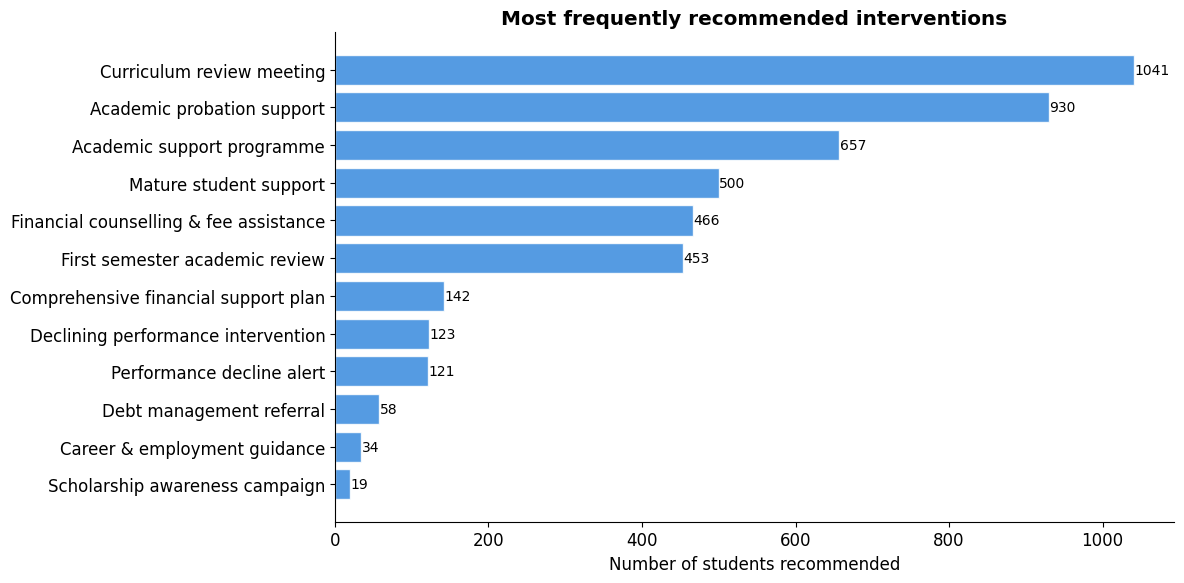

In [6]:
# ── 5a. Most recommended interventions ───────────────────────────────────────
top_interventions = (
    recommendations_df.groupby('intervention_title')
    .size()
    .sort_values(ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top_interventions.index[::-1],
    top_interventions.values[::-1],
    color='#378ADD', edgecolor='white', alpha=0.85
)
for bar, val in zip(bars, top_interventions.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_xlabel('Number of students recommended')
ax.set_title('Most frequently recommended interventions', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/top_interventions.png', dpi=150, bbox_inches='tight')
plt.show()

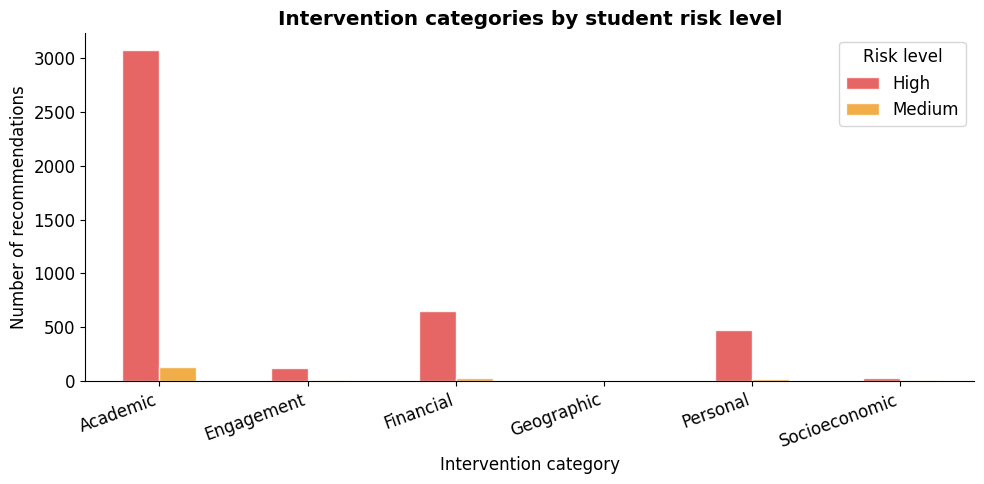

In [7]:
# ── 5b. Recommendations by category and risk level ───────────────────────────
cat_risk = pd.crosstab(
    recommendations_df['risk_category'],
    recommendations_df['risk_level']
).reindex(columns=['High', 'Medium'], fill_value=0)

cat_risk.plot(
    kind='bar',
    color=['#E24B4A', '#EF9F27'],
    edgecolor='white', alpha=0.85, figsize=(10, 5)
)
plt.title('Intervention categories by student risk level', fontweight='bold')
plt.xlabel('Intervention category')
plt.ylabel('Number of recommendations')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Risk level')
plt.tight_layout()
plt.savefig('../data/processed/recommendations_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

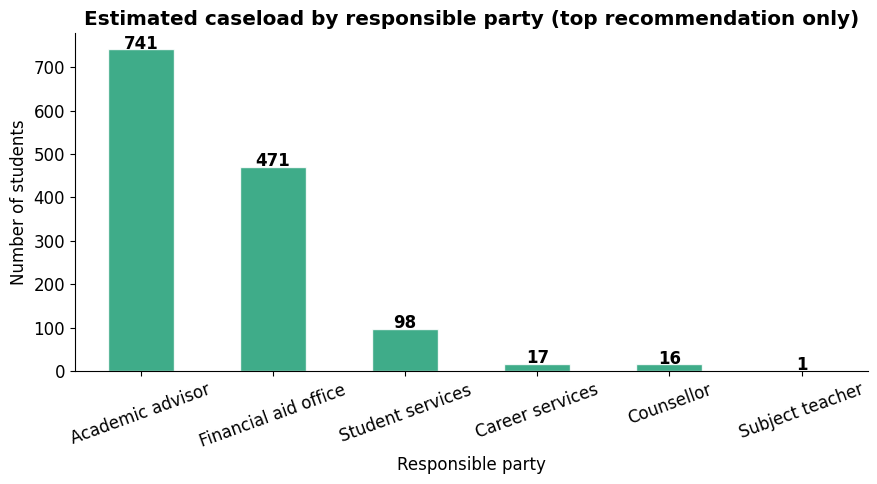

In [8]:
# ── 5c. Responsible party workload ───────────────────────────────────────────
party_counts = (
    recommendations_df[recommendations_df['rec_rank'] == 1]
    .groupby('responsible_party')
    .size()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
party_counts.plot(kind='bar', ax=ax, color='#1D9E75', edgecolor='white', alpha=0.85)
ax.set_title('Estimated caseload by responsible party (top recommendation only)', fontweight='bold')
ax.set_xlabel('Responsible party')
ax.set_ylabel('Number of students')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(party_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/responsible_party_workload.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Sample Student Report

This is the format the Streamlit app will display for each student.

In [9]:
def print_student_report(student_idx, full_df, shap_df, shap_cols, FEATURE_NAMES, rules):
    risk_score = shap_df.loc[student_idx, 'risk_score']
    risk_level = assign_risk_level(risk_score)

    student_features = full_df[FEATURE_NAMES].iloc[student_idx]
    student_shap     = shap_df[shap_cols].iloc[student_idx]
    student_shap.index = FEATURE_NAMES

    recs = get_recommendations(
        student_features, student_shap, FEATURE_NAMES, rules, top_n_factors=5
    )

    risk_colors = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}
    urgency_colors = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}

    print('=' * 65)
    print(f'  STUDENT DROPOUT RISK REPORT')
    print('=' * 65)
    print(f'  Student ID    : {student_idx}')
    print(f'  Risk Score    : {risk_score:.4f}  ({risk_score*100:.1f}%)')
    print(f'  Risk Level    : {risk_colors.get(risk_level, "")} {risk_level}')
    print()

    # Top risk factors
    shap_series = pd.Series(student_shap.values, index=FEATURE_NAMES)
    top_factors = shap_series[shap_series > 0].nlargest(5)

    print('  TOP RISK FACTORS (SHAP-driven)')
    print('  ' + '-' * 50)
    for rank, (feat, val) in enumerate(top_factors.items(), 1):
        feat_val = student_features[feat]
        print(f'  {rank}. {feat}')
        print(f'     Value: {feat_val:.2f}  |  SHAP contribution: +{val:.4f}')
    print()

    # Recommendations
    print(f'  RECOMMENDED INTERVENTIONS ({len(recs)} actions)')
    print('  ' + '-' * 50)
    for i, rec in enumerate(recs, 1):
        print(f'  [{i}] {rec["intervention_title"]}')
        print(f'      Category  : {rec["risk_category"]}')
        print(f'      Urgency   : {urgency_colors.get(rec["urgency"], "")} {rec["urgency"]}')
        print(f'      Action by : {rec["responsible_party"]}')
        print(f'      Detail    : {rec["intervention_detail"][:100]}...')
        print()
    print('=' * 65)


# Print a report for the highest risk student
high_risk_idx = shap_df['risk_score'].idxmax()
print_student_report(high_risk_idx, full_df, shap_df, shap_cols, FEATURE_NAMES, rules)

  STUDENT DROPOUT RISK REPORT
  Student ID    : 1134
  Risk Score    : 0.9997  (100.0%)
  Risk Level    : 🔴 High

  TOP RISK FACTORS (SHAP-driven)
  --------------------------------------------------
  1. Tuition fees up to date
     Value: 0.00  |  SHAP contribution: +2.2242
  2. Approval_Rate_Sem2
     Value: 0.00  |  SHAP contribution: +0.9670
  3. Total_Units_Failed
     Value: 12.00  |  SHAP contribution: +0.9286
  4. Curricular units 2nd sem (evaluations)
     Value: 0.00  |  SHAP contribution: +0.5530
  5. Curricular units 2nd sem (approved)
     Value: 0.00  |  SHAP contribution: +0.3689

  RECOMMENDED INTERVENTIONS (4 actions)
  --------------------------------------------------
  [1] Financial counselling & fee assistance
      Category  : Financial
      Urgency   : 🔴 High
      Action by : Financial aid office
      Detail    : Connect the student with the financial aid office immediately. Explore available scholarships, bursa...

  [2] Curriculum review meeting
      Categ

---
## 7. Save Everything

In [10]:
# Save full recommendations dataframe
recommendations_df.to_csv('../data/processed/all_recommendations.csv', index=False)
print('All recommendations saved to ../data/processed/all_recommendations.csv')

# Save the engine functions as a module for Streamlit
engine_code = '''
import pandas as pd
import json

URGENCY_WEIGHT = {"High": 3, "Medium": 2, "Low": 1}

def assign_risk_level(score):
    if score >= 0.70:
        return "High"
    elif score >= 0.40:
        return "Medium"
    else:
        return "Low"

def match_rules(feature_name, feature_value, shap_value, rules):
    matched = []
    for rule in rules:
        if rule["trigger_feature"] != feature_name:
            continue
        condition = rule["condition"]
        threshold = rule["threshold"]
        triggered = False
        if condition == "low"    and feature_value <= threshold: triggered = True
        elif condition == "high" and feature_value >= threshold: triggered = True
        elif condition == "equals" and int(feature_value) == int(threshold): triggered = True
        if triggered:
            matched.append({
                "rule_id"            : rule["id"],
                "risk_category"      : rule["risk_category"],
                "intervention_title" : rule["intervention_title"],
                "intervention_detail": rule["intervention_detail"],
                "responsible_party"  : rule["responsible_party"],
                "urgency"            : rule["urgency"],
                "trigger_feature"    : feature_name,
                "feature_value"      : feature_value,
                "shap_value"         : shap_value
            })
    return matched

def get_recommendations(student_features, student_shap_values, feature_names, rules, top_n_factors=5):
    shap_series = pd.Series(student_shap_values, index=feature_names)
    top_factors = shap_series[shap_series > 0].nlargest(top_n_factors)
    all_recommendations = []
    seen_titles = set()
    for feature_name, shap_val in top_factors.items():
        feature_val = student_features[feature_name]
        matches = match_rules(feature_name, feature_val, shap_val, rules)
        for rec in matches:
            if rec["intervention_title"] not in seen_titles:
                seen_titles.add(rec["intervention_title"])
                rec["priority_score"] = round(shap_val * URGENCY_WEIGHT[rec["urgency"]], 4)
                all_recommendations.append(rec)
    all_recommendations.sort(key=lambda x: x["priority_score"], reverse=True)
    return all_recommendations
'''

with open('../src/recommender.py', 'w') as f:
    f.write(engine_code)
print('Recommender module saved to ../src/recommender.py')

All recommendations saved to ../data/processed/all_recommendations.csv
Recommender module saved to ../src/recommender.py


---
## 8. Summary

In [11]:
print('=' * 65)
print('  RECOMMENDATION ENGINE SUMMARY')
print('=' * 65)

high_count   = (shap_df['risk_score'] >= 0.70).sum()
medium_count = ((shap_df['risk_score'] >= 0.40) & (shap_df['risk_score'] < 0.70)).sum()
low_count    = (shap_df['risk_score'] < 0.40).sum()

print(f"""
Intervention library  : {len(rules)} rules across 6 categories
  Academic            : {sum(1 for r in rules if r['risk_category'] == 'Academic')}
  Financial           : {sum(1 for r in rules if r['risk_category'] == 'Financial')}
  Geographic          : {sum(1 for r in rules if r['risk_category'] == 'Geographic')}
  Engagement          : {sum(1 for r in rules if r['risk_category'] == 'Engagement')}
  Personal            : {sum(1 for r in rules if r['risk_category'] == 'Personal')}
  Socioeconomic       : {sum(1 for r in rules if r['risk_category'] == 'Socioeconomic')}

Students processed    : {len(full_df)}
  High risk  (>=0.70) : {high_count}
  Medium risk (0.40-0.70): {medium_count}
  Low risk   (<0.40)  : {low_count}

Recommendations generated
  At-risk students    : {at_risk_students}
  Total interventions : {len(recommendations_df)}
  Avg per student     : {len(recommendations_df)/at_risk_students:.1f}

Saved artifacts
  ../data/processed/all_recommendations.csv
  ../src/recommender.py
  ../app/intervention_library.json

Next step -> Streamlit dashboard
""")
print('=' * 65)

  RECOMMENDATION ENGINE SUMMARY

Intervention library  : 20 rules across 6 categories
  Academic            : 8
  Financial           : 4
  Geographic          : 1
  Engagement          : 3
  Personal            : 3
  Socioeconomic       : 1

Students processed    : 4424
  High risk  (>=0.70) : 1322
  Medium risk (0.40-0.70): 105
  Low risk   (<0.40)  : 2997

Recommendations generated
  At-risk students    : 1344
  Total interventions : 4568
  Avg per student     : 3.4

Saved artifacts
  ../data/processed/all_recommendations.csv
  ../src/recommender.py
  ../app/intervention_library.json

Next step -> Streamlit dashboard

